<div style="max-width:300px; float: left; margin-right: 1em">

![](Figures/fcfm_das.svg)

</div>
<span style="color: red;">Departamento de Astronomía, Universidad de Chile</span> <br>
Facultad de Ciencias Físicas y Matemáticas <br>
Universidad de Chile <br>
AS4501 - Astroinformatica <br>
Otoño 2026 <br>
Profesor: Francisco Förster Burón <br>
<strong>Profesores Auxilares y Autores: Benjamin Carrera y Steve Jurado</strong> <br>

> This notebook is created based on the notes from 
> - ([@fforster](https://github.com/fforster)) Francisco Förster: - **Main Notes 2026/01**   
>   - https://github.com/fforster/AS4501/tree/main
> - ([@thevalentino](https://github.com/thevalentino)) Valentino Gonzales:
>   - https://github.com/thevalentino/AS450-astroinformatica
> - ([@cefuente](https://github.com/cefuente)) Cesar Fuentes
>   - https://github.com/cefuente/astroinformatica
> 
> and previour teachers assistants
> - ([@m-fuentealba](https://github.com/m-fuentealba)) Melissa Fuentealba 
> - ([@jvines](https://github.com/jvines)) José Vines
> - ([@PauCaBu](https://github.com/PauCaBu)) Paula Cáceres Burgos
> - ([@JavieraTGrey](https://github.com/JavieraTGrey)) Javiera Toro Grey

In [1]:
import io
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rc_params = {
    # --- Fonts and text ---
    'mathtext.fontset': 'cm',     # Set default mathtext font
    'font.family': 'STIXGeneral', # Set default font family
    
    # --- Figure and axes ---
    'font.size': 12,              # Set default font size
    'axes.labelsize': 16,         # Set default axes label size
    'axes.titlesize': 16,         # Set default axes title size
    'xtick.labelsize': 14,        # Set default axes label size
    'ytick.labelsize': 14,        # Set default axes label size
    'legend.fontsize': 14,        # Set default legend font size
    
    # --- Configuration of ticks ---
    'xtick.direction': 'in',      # Set default xtickdirecion
    'ytick.direction': 'in',      # Set default ytickdirecion
    'xtick.minor.visible': True,  # visibility of minor ticks on x-axis
    'ytick.minor.visible': True,  # visibility of minor ticks on y-axis


    'grid.linestyle': ':',        # Set grid linestyle
    'grid.alpha': 0.6,            # Set grid transparency
    
    # --- Figure size ---
    'figure.figsize': (8, 6),     # Ideal proportion for one MNRAS column
}
plt.rcParams.update(rc_params)

¡Claro que sí! Los asteroides son un caso de estudio excelente porque permiten visualizar "familias" de forma muy intuitiva usando sus elementos orbitales.

  Aquí tienes una propuesta de estructura para el auxiliar, diseñada para ser progresiva y fácil de seguir:

  1. Obtención y Preparación de Datos (JPL)
   * Descarga de datos: Usar astroquery.jplsbdb para obtener una muestra de asteroides (por ejemplo, los del Cinturón Principal).
   * Selección de variables: Enfocarse en los elementos orbitales clásicos: semieje mayor ($a$), excentricidad ($e$), inclinación ($i$), y quizás el diámetro
     o albedo si están disponibles.
   * Importancia del Escalamiento: Explicar por qué es obligatorio usar StandardScaler o MinMaxScaler antes de cualquier algoritmo no supervisado, ya que las
     unidades de los ángulos y las distancias son muy distintas.

  2. Reducción de Dimensionalidad (PCA)
   * Visualización: Usar PCA para comprimir los 5-6 parámetros orbitales en 2 dimensiones principales. 
   * Interpretación: Analizar la "varianza explicada". ¿Qué elementos orbitales influyen más en la forma de la nube de datos?
   * Gráficos: Hacer un scatter plot de los componentes principales para ver si se empiezan a notar agrupaciones naturales antes de aplicar clustering.

  3. Clustering: Identificando Familias de Asteroides
   * K-Means (El clásico): 
       * Usar el "Método del Codo" (Elbow Method) o el Coeficiente de Silueta para que los alumnos decidan cuántas familias de asteroides existen en la
         muestra.
       * Visualizar los centroides en el espacio de elementos orbitales reales (ej: $a$ vs $e$).
   * DBSCAN (Basado en densidad): 
       * Explicar que este es ideal para asteroides porque las familias suelen ser densas y estar rodeadas de un "ruido" de asteroides de fondo.
       * Es muy útil para detectar outliers (asteroides que no pertenecen a ninguna familia conocida).

  4. Gaussian Mixture Models (GMM)
   * Modelado Probabilístico: A diferencia de K-Means, explicar cómo GMM permite que un asteroide tenga una probabilidad de pertenecer a una familia u otra
     (soft clustering).
   * Criterio de Selección: Usar el BIC (Bayesian Information Criterion) para encontrar el número óptimo de componentes, conectando con la parte estadística
     del curso.

  5. El "Puente" hacia Supervised Learning (Bonus)
   * Clasificación: Si los datos del JPL traen etiquetas de familias (ej: Flora, Vesta, Koronis), comparar si los clusters encontrados coinciden con las
     familias taxonómicas conocidas.
   * Regresión: Una vez identificados los clusters, podrías intentar predecir el albedo (brillo) de un asteroide basándote en su pertenencia a un cluster y
     sus elementos orbitales.

  ¿Qué te parece este enfoque? Si estás de acuerdo, puedo ayudarte a redactar el código de ejemplo para descargar los datos del JPL o la estructura inicial
  del Notebook.


In [57]:
import requests
import pandas as pd
import json

url = "https://ssd-api.jpl.nasa.gov/sbdb_query.api"

# Filtros: diameter is defined AND albedo is defined
# Quitamos sb-group porque para asteroides generales no es necesario
filtros = {
    "AND": [
        "diameter|DF",
        "albedo|DF"
    ]
}

params = {
    "fields": "full_name,a,e,i,H,diameter,albedo",
    "sb-cdata": json.dumps(filtros),
    "limit": "1000"
}

print("Consultando JPL (Cinturón Principal + otros)...")

try:
    r = requests.get(url, params=params)
    r.raise_for_status()
    res = r.json()
    
    if 'data' in res:
        df_org = pd.DataFrame(res['data'], columns=res['fields'])
        
        # Convertimos a numérico
        cols_num = ['a', 'e', 'i', 'H', 'diameter', 'albedo']
        df_org[cols_num] = df_org[cols_num].apply(pd.to_numeric, errors='coerce')
        
        # Limpieza de nombres (quitar paréntesis o espacios extra)
        df_org['full_name'] = df_org['full_name'].str.strip()
        
        # Renombrar para tu consistencia en la VAE
        df_org = df_org.rename(columns={'full_name': 'objID', 'diameter': 'D', 'albedo': 'pv'})
        
        print(f"¡Logrado! {len(df_org)} objetos cargados.")
        print(df_org.head())
    else:
        print("La respuesta no contiene datos. Respuesta del servidor:", res)
        
except Exception as e:
    print(f"Error: {e}")
    if 'r' in locals():
        print(f"Texto del servidor: {r.text}")

Consultando JPL (Cinturón Principal + otros)...


¡Logrado! 1000 objetos cargados.
                 objID      a       e      i     H        D      pv
0    1 Ceres (A801 AA)  2.766  0.0796  10.59  3.35  939.400  0.0900
1   2 Pallas (A802 FA)  2.770  0.2306  34.93  4.11  513.000  0.1550
2     3 Juno (A804 RA)  2.671  0.2558  12.99  5.19  246.596  0.2140
3    4 Vesta (A807 FA)  2.362  0.0902   7.14  3.25  522.770  0.4228
4  5 Astraea (A845 XA)  2.577  0.1875   5.36  6.96  106.699  0.2740


In [58]:
df_org.shape, df_org.columns, df_org.head()

((1000, 7),
 Index(['objID', 'a', 'e', 'i', 'H', 'D', 'pv'], dtype='str'),
                  objID      a       e      i     H        D      pv
 0    1 Ceres (A801 AA)  2.766  0.0796  10.59  3.35  939.400  0.0900
 1   2 Pallas (A802 FA)  2.770  0.2306  34.93  4.11  513.000  0.1550
 2     3 Juno (A804 RA)  2.671  0.2558  12.99  5.19  246.596  0.2140
 3    4 Vesta (A807 FA)  2.362  0.0902   7.14  3.25  522.770  0.4228
 4  5 Astraea (A845 XA)  2.577  0.1875   5.36  6.96  106.699  0.2740)

| Parámetro | Descripción | Unidades |
|-----------|-------------|----------|
| `objID` | Identificador del asteroide | — |
| `a` | Semieje mayor orbital | AU |
| `e` | Excentricidad orbital | — |
| `i` | Inclinación orbital respecto al plano eclíptico | grados |
| `H` | Magnitud absoluta (brillo intrínseco) | mag |
| `D` | Diámetro | km |
| `pv` | Albedo geométrico (fracción de luz reflejada) | — |


Las tres variables físicas del asteroide — magnitud absoluta $H$, diámetro $D$ y albedo geométrico $p_v$ — no son independientes. Están vinculadas por la relación empírica:

$$\log_{10} D = \log_{10} 1329 - \frac{1}{2}\log_{10} p_v - \frac{H}{5}$$

Esto significa que conocer dos de ellas determina completamente la tercera. En un análisis de aprendizaje no supervisado, incluir las tres simultáneamente sobrerepresenta la información de tamaño y brillo del asteroide, dándole artificialmente más peso en la separación de grupos.

Por esta razón, se recomienda retener solo H (que combina intrínsecamente ambas propiedades) o bien seleccionar una de las tres según el contexto físico del análisis, evitando redundancia en el espacio de características.

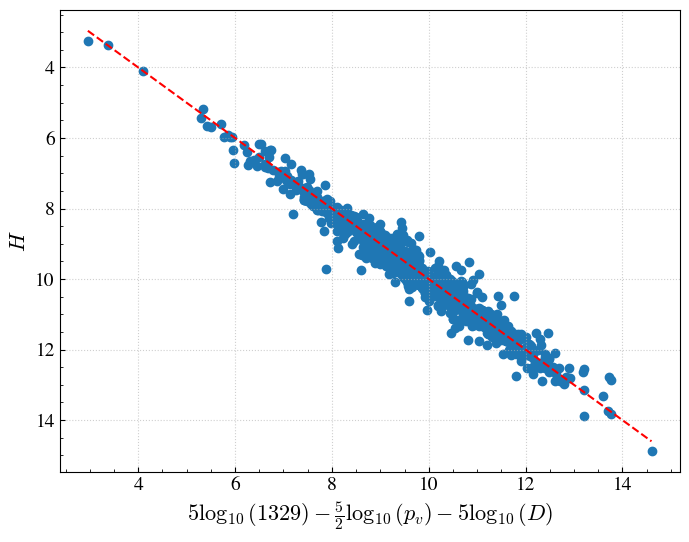

In [59]:
x_combo = -5/2*np.log10(df_org.pv)-5*np.log10(df_org.D) + 5*np.log10(1329)
fig, ax = plt.subplots()
ax.scatter(-5/2*np.log10(df_org.pv)-5*np.log10(df_org.D) + 5*np.log10(1329), df_org.H)
ax.set_xlabel(r'$5\log_{10}(1329) - \frac{5}{2}\log_{10}(p_v) - 5\log_{10}(D)$')
ax.plot([x_combo.min(), x_combo.max()],
        [x_combo.min(), x_combo.max()], 'r--', label='y = x')
ax.set_ylabel(r'$H$')
ax.invert_yaxis()
ax.grid()
plt.show()

In [60]:
df = df_org.drop(['H'],axis=1)
df['sini']  = np.sin(np.radians(df.i))
df['logD']  = np.log10(df.D)
df['logpv'] = np.log10(df.pv)
df = df.drop(['i','D','pv'], axis=1)
df.shape, df.columns, df.head()

((1000, 6),
 Index(['objID', 'a', 'e', 'sini', 'logD', 'logpv'], dtype='str'),
                  objID      a       e      sini      logD     logpv
 0    1 Ceres (A801 AA)  2.766  0.0796  0.183780  2.972851 -1.045757
 1   2 Pallas (A802 FA)  2.770  0.2306  0.572575  2.710117 -0.809668
 2     3 Juno (A804 RA)  2.671  0.2558  0.224781  2.391986 -0.669586
 3    4 Vesta (A807 FA)  2.362  0.0902  0.124294  2.718311 -0.373865
 4  5 Astraea (A845 XA)  2.577  0.1875  0.093413  2.028160 -0.562249)

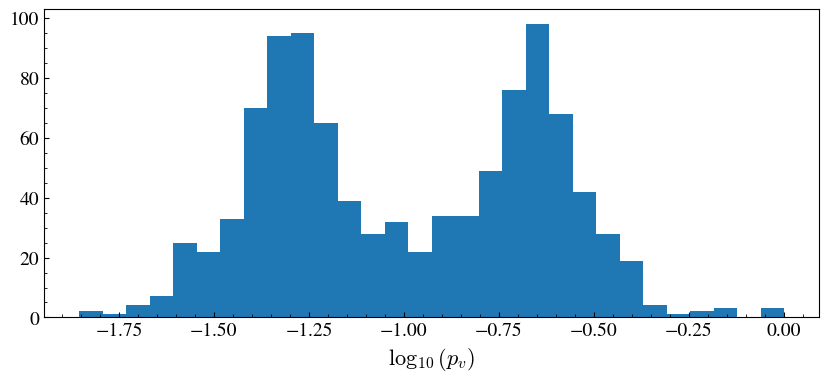

In [6]:
fig, axes = plt.subplots(figsize=(10, 4))
axes.hist(df.logpv, bins=30)
axes.set_xlabel(r'$\log_{10}(p_v)$')
plt.show()

## Dimensional Reduction

### Princiapl Component Analysis (PCA)

El Análisis de Componentes Principales (PCA) es una técnica de transformación lineal que busca un nuevo sistema de coordenadas para los datos. El objetivo es que el primer eje (PC1) capture la mayor cantidad de varianza posible, el segundo (PC2) la segunda mayor, y así sucesivamente. Los nuevos ejes son ortogonales entre sí y están ordenados de mayor a menor varianza explicada.

El PCA requiere que los datos estén centrados en el origen. Si no restamos la media, el primer componente principal apuntaría desde el origen hacia el centro de la nube de puntos, lo cual no captura la varianza interna sino solo la posición media.

Supón que tienes $n$ observaciones y $p$ variables. La matriz de datos es:

$$\mathbf{X} = \begin{pmatrix} x_{11} & x_{12} & \cdots & x_{1p} \\ 
x_{21} & x_{22} & \cdots & x_{2p} \\
 \vdots & & \ddots & \vdots \\ 
x_{n1} & x_{n2} & \cdots & x_{np} 
\end{pmatrix}$$

El vector de medias de cada columna es:

$$\boldsymbol{\mu} = \begin{pmatrix} \mu_1 \\ \mu_2 \\ \vdots \\ \mu_p \end{pmatrix}, \qquad \mu_j = \frac{1}{n}\sum_{i=1}^n x_{ij}$$

La matriz centrada se obtiene restando la media de cada columna:

$$\mathbf{B} = \mathbf{X} - \mathbf{1}\boldsymbol{\mu}^T = \begin{pmatrix} x_{11}-\mu_1 & x_{12}-\mu_2 & \cdots & x_{1p}-\mu_p \\ x_{21}-\mu_1 & x_{22}-\mu_2 & \cdots & x_{2p}-\mu_p \\ \vdots & & \ddots & \vdots \\ x_{n1}-\mu_1 & x_{n2}-\mu_2 & \cdots & x_{np}-\mu_p \end{pmatrix}$$

Ejemplo numérico (4 asteroides, 2 variables: $a$ y $\log p_v$):

$$\mathbf{X} = \begin{pmatrix} 2.5 & -1.4 \\ 3.1 & -1.2 \\ 2.8 & -0.7 \\ 3.4 & -0.6 \end{pmatrix}, \qquad \boldsymbol{\mu} = \begin{pmatrix} 2.95 \\ -0.975 \end{pmatrix}$$

$$\mathbf{B} = \begin{pmatrix} -0.45 & -0.425 \\ 0.15 & -0.225 \\ -0.15 & 0.275 \\ 0.45 & 0.375 \end{pmatrix}$$
---

La matriz de covarianza resume cómo varían conjuntamente las variables:

$$\mathbf{C} = \frac{1}{n-1} \mathbf{B}^T \mathbf{B} = \begin{pmatrix} \text{Var}(x_1) & \text{Cov}(x_1, x_2) & \cdots \\ \text{Cov}(x_2, x_1) & \text{Var}(x_2) & \cdots \\ \vdots & & \ddots \end{pmatrix}$$

- **Diagonal:** varianza de cada variable
- **Fuera de la diagonal:** covarianza entre pares — si es positiva, crecen juntas; si es negativa, una crece cuando la otra decrece

Ejemplo numérico:

$$\mathbf{C} = \frac{1}{3}\mathbf{B}^T\mathbf{B} = \begin{pmatrix} 0.1467 & 0.1192 \\ 0.1192 & 0.1092 \end{pmatrix}$$

La covarianza positiva indica que los asteroides con $a$ mayor tienden a tener $\log p_v$ más alto (menos oscuros).

---

El PCA busca una dirección (vector unitario $\mathbf{w}$) tal que la varianza de los datos proyectados sobre él sea máxima. La varianza proyectada es:

$$\text{Var}(\mathbf{B}\mathbf{w}) = \mathbf{w}^T \mathbf{C}, \mathbf{w}$$

Maximizar esto con la restricción $|\mathbf{w}| = 1$ (usando multiplicadores de Lagrange) lleva a la ecuación de autovalores:

$$\mathbf{C}\mathbf{w} = \lambda\mathbf{w}$$

Los autovalores $\lambda_i$ indican cuánta varianza hay en cada dirección; los autovectores $\mathbf{v}_i$ son esas direcciones.

Ejemplo numérico: para $\mathbf{C}$ de arriba, los autovalores son $\lambda_1 \approx 0.245$, $\lambda_2 \approx 0.011$ y los autovectores:

$$\mathbf{v}_1 = \begin{pmatrix} 0.758 \ 0.652 \end{pmatrix}, \qquad \mathbf{v}_2 = \begin{pmatrix} -0.652 \ 0.758 \end{pmatrix}$$

PC1 apunta en la dirección de mayor dispersión (combinación de $a$ y $\log p_v$); PC2 es perpendicular a PC1.

---

$$\text{Varianza Explicada}k = \frac{\lambda_k}{\sum{i=1}^{p} \lambda_i}$$

Ejemplo: $\lambda_1 + \lambda_2 = 0.256$, entonces PC1 explica $0.245/0.256 \approx 96%$ de la varianza total. Con una sola componente ya capturas casi toda la información.

---

Seleccionamos los $k$ autovectores con mayor autovalor y formamos la matriz de loadings $\mathbf{V}_k \in \mathbb{R}^{p \times k}$:

$$\mathbf{V}_k = \begin{pmatrix} | & | & \cdots \\ \mathbf{v}_1 & \mathbf{v}_2 & \cdots \\ | & | & \cdots \end{pmatrix}$$

Las nuevas coordenadas (scores) de cada observación en el espacio reducido son:

$$\mathbf{Z} = \mathbf{B}\mathbf{V}_k$$

Ejemplo proyectando sobre PC1 ($k=1$):

$$\mathbf{Z} = \begin{pmatrix} -0.45 & -0.425 \\ 0.15 & -0.225 \\ -0.15 & 0.275 \\ 0.45 & 0.375 \end{pmatrix} \begin{pmatrix} 0.758 \ 0.652 \end{pmatrix} = \begin{pmatrix} -0.618 \\ -0.033 \\ 0.066 \\ 0.585 \end{pmatrix}$$

Cada fila es la coordenada del asteroide en el nuevo eje PC1. Lo que era una tabla de 4×2 se redujo a un vector de 4×1 conservando el 96% de la información

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


features = df.columns[1:]
X = df[features]

# 1. Escalamiento
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

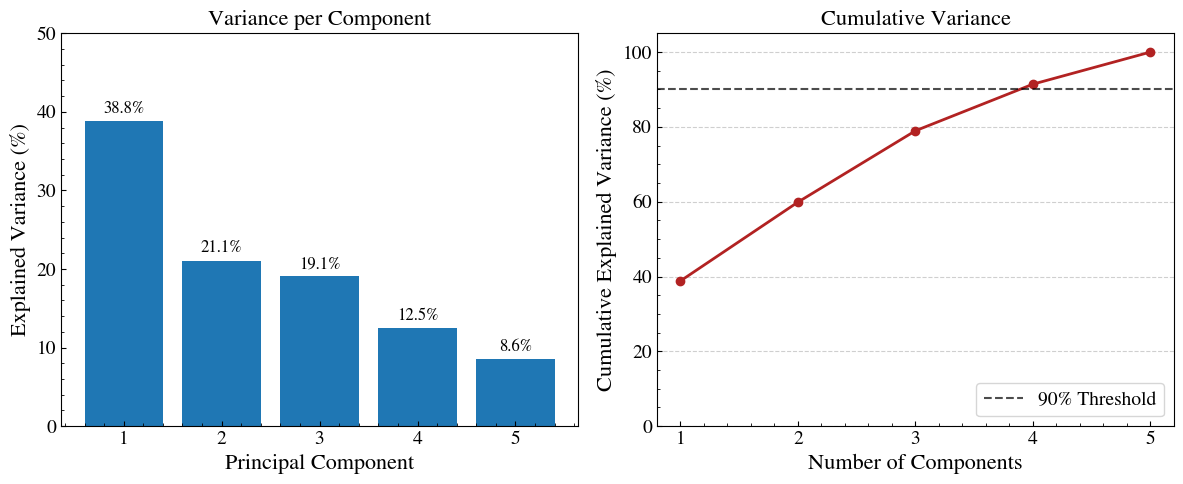

Total Variance Explained by first 2 components: 59.89%


In [20]:
# The maximum number of components is equal to the number of features
n_features = X.shape[1]
pca_full = PCA(n_components=n_features)
pca_full.fit(X_scaled)

# Calculating variance percentages
exp_var_ratio = pca_full.explained_variance_ratio_ * 100
cum_var_ratio = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Individual Explained Variance
bars = axes[0].bar(range(1, n_features + 1), exp_var_ratio)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Variance per Component')
axes[0].set_xticks(range(1, n_features + 1))
axes[0].set_ylim(0, 50)
# Adding labels over each bar
axes[0].bar_label(bars, fmt='%.1f%%', padding=3)

# 2. Cumulative Explained Variance
axes[1].plot(range(1, n_features + 1), cum_var_ratio, 'o-', color='firebrick', linewidth=2)
axes[1].axhline(90, color='black', linestyle='--', alpha=0.7, label='90% Threshold')


# Adding text for the 90% threshold for clarity
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Variance')
axes[1].set_xticks(range(1, n_features + 1))
axes[1].set_ylim(0, 105)
axes[1].legend(loc='lower right')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Print summary to console
print(f"Total Variance Explained by first 2 components: {cum_var_ratio[1]:.2f}%")


   Feature        a         e      sini      logD     logpv
------------------------------------------------------------
PC1           0.535    -0.111     0.053     0.604    -0.578
PC2           0.080    -0.676     0.704    -0.083     0.181


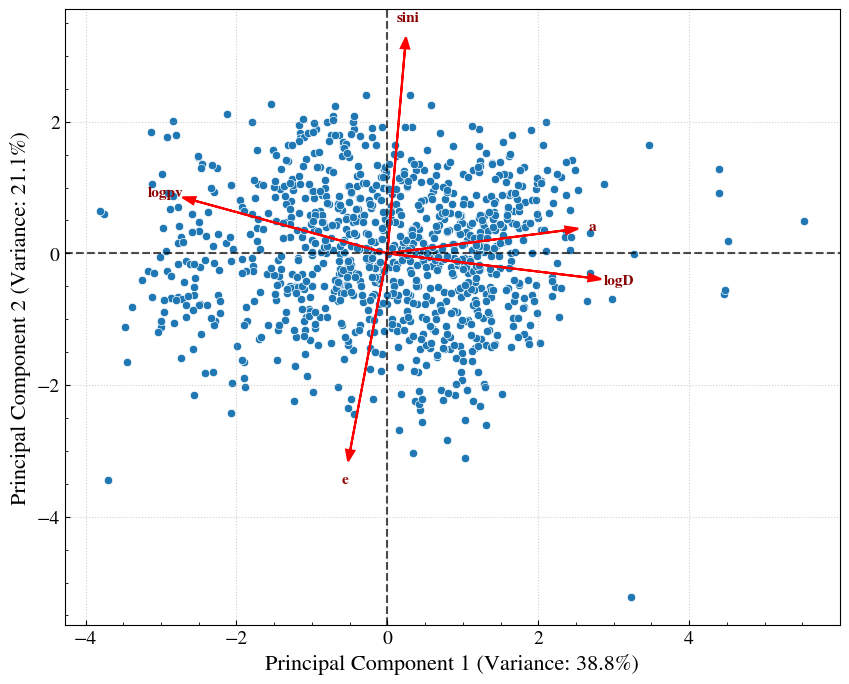

In [31]:
# --- PCA Execution ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# --- Print Loading Matrix (Component Weights) ---
loadings = pca.components_
print(f"\n{'Feature':>10} " + "  ".join(f"{f:>8}" for f in features))
print("-" * (10 + 10 * len(features)))
for i, row in enumerate(loadings):
    print(f"PC{i+1:<8} " + "  ".join(f"{v:>8.3f}" for v in row))

# --- Biplot Scaling Calculation ---
# Scale arrows to match the score distribution (80% of max score)
max_score = np.max(np.abs(X_pca))
scaling_factor = max_score * 0.8 

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot of asteroid scores
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], ax=ax)

# Project original features as vectors (arrows)
for i, feature in enumerate(features):
    x_vec = loadings[0, i] * scaling_factor
    y_vec = loadings[1, i] * scaling_factor
    
    # Draw arrow from origin
    ax.arrow(0, 0, x_vec, y_vec, color='red', 
             head_width=max_score*0.02, head_length=max_score*0.03, lw=1.5)
    
    # Feature labels with slight offset
    ax.text(x_vec * 1.15, y_vec * 1.15, feature, color='darkred', 
            ha='center', va='center', fontweight='bold', fontsize=11)

# --- Plot Formatting ---
ax.axhline(0, color='black', linestyle='--', alpha=0.7)
ax.axvline(0, color='black', linestyle='--', alpha=0.7)

# Dynamic labels with explained variance
var_exp = pca.explained_variance_ratio_ * 100
ax.set_xlabel(f'Principal Component 1 (Variance: {var_exp[0]:.1f}%)')
ax.set_ylabel(f'Principal Component 2 (Variance: {var_exp[1]:.1f}%)')

ax.grid(True, linestyle=':', alpha=0.6)
plt.show()

La dirección y longitud de cada flecha indica cuánto y en qué sentido contribuye cada variable a PC1 y PC2.

**PC1 (eje horizontal, 38.8%)**: Separa principalmente por tamaño y tipo taxonómico.

- `a` y logD apuntan hacia la derecha → asteroides grandes con órbitas externas (cinturón exterior)
- `logpv` apunta hacia la izquierda → alto albedo se asocia con asteroides más pequeños y brillantes (tipo S, cinturón interior)
- `logpv` es casi opuesto a `a` y logD: los asteroides más grandes tienden a ser oscuros (tipo C), los más brillantes tienden a ser pequeños

**PC2 (eje vertical, 21.1%):** Captura la geometría orbital.

- `sini` apunta hacia arriba → órbitas muy inclinadas
- e apunta hacia abajo → alta excentricidad
- Son casi opuestos: existe un tradeoff entre inclinación y excentricidad en las familias orbitales

| Par | Ángulo | Interpretación |
|-----|--------|----------------|
| `a` — `logD` | ~pequeño | Correlacionadas: asteroides grandes están en el cinturón exterior |
| `logpv` — `logD` | ~180° | Anti-correladas: mayor tamaño → menor albedo |
| `sini` — `e` | ~opuestos | Anti-correladas en PC2 |
| `sini` — `a` | ~90° | Independientes |


**Nube de puntos:** No se ven clusters separados claramente en 2D — esto es esperado porque PC1+PC2 solo explican el 59.9% de la varianza. La estructura de grupos estará más definida en las 4 dimensiones que elegiste para el clustering.

### (Uniform Manifold Approximation and Projection) UMAP

UMAP (Uniform Manifold Approximation and Projection) es una técnica de reducción de dimensión no lineal. A diferencia del PCA (que solo encuentra direcciones lineales), UMAP puede capturar estructuras curvas y no lineales en los datos.

La idea central: preservar la topología local — puntos que son vecinos en alta dimensión deben seguir siendo vecinos en 2D.

¿Es mejor que PCA para ver clusters?
PCA	UMAP
Tipo	Lineal	No lineal
Preserva	Varianza global	Estructura local/vecindad
Clusters	Los comprime, puede solaparlos	Los separa visualmente mejor
Interpretable	Sí (loadings)	No — los ejes no tienen significado físico
Determinista	Sí	No (depende de random_state)
Velocidad	Rápido	Más lento
UMAP es mejor para visualizar clusters, pero no debes hacer clustering directamente sobre el embedding UMAP — las distancias entre grupos se distorsionan. Úsalo solo para visualización.

In [61]:
try: 
    import umap
except:
    !pip install umap-learn
    import umap

/home/jurados/AS4501_Astroinformatic/Astroinformatic/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


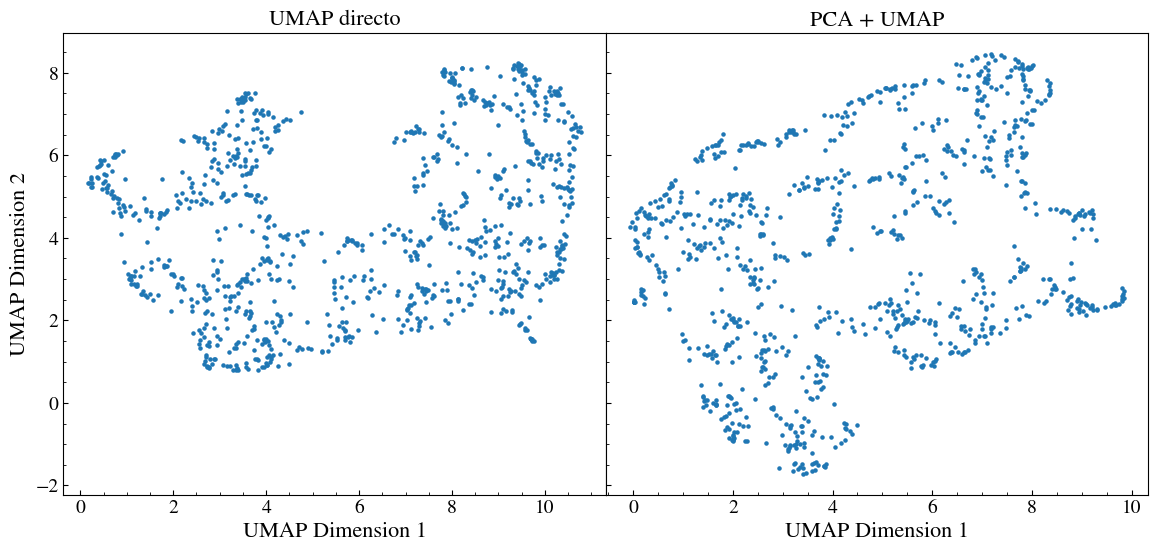

In [62]:
# 1. Dimensionality Reduction Pre-processing
# Applying PCA to reduce noise and capture 4 main components before UMAP
pca = PCA(n_components=4)
X_pca_preprocessed = pca.fit_transform(X_scaled)

# 2. UMAP Embedding Generation
# We initialize one reducer. Using a random_state ensures reproducibility.
reducer = umap.UMAP(random_state=42)

# Embedding 1: Direct UMAP on scaled features
# This captures the non-linear manifold of the raw (scaled) data
original_embedding = reducer.fit_transform(X_scaled)

# Embedding 2: UMAP on PCA-preprocessed data
# Common practice to speed up computation and filter noise
pca_pre_embedding = reducer.fit_transform(X_pca_preprocessed)

# 3. Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, gridspec_kw={'wspace': 0})
axes[0].scatter(original_embedding[:, 0], original_embedding[:, 1],s=5)
axes[0].set_xlabel('UMAP Dimension 1')
axes[0].set_ylabel('UMAP Dimension 2')
axes[0].set_title('UMAP directo')

sc1 = axes[1].scatter(pca_pre_embedding[:, 0], pca_pre_embedding[:, 1],s=5)
axes[1].set_xlabel('UMAP Dimension 1')
axes[1].set_title('PCA + UMAP')
axes[1].tick_params(labelleft=False)

plt.show()

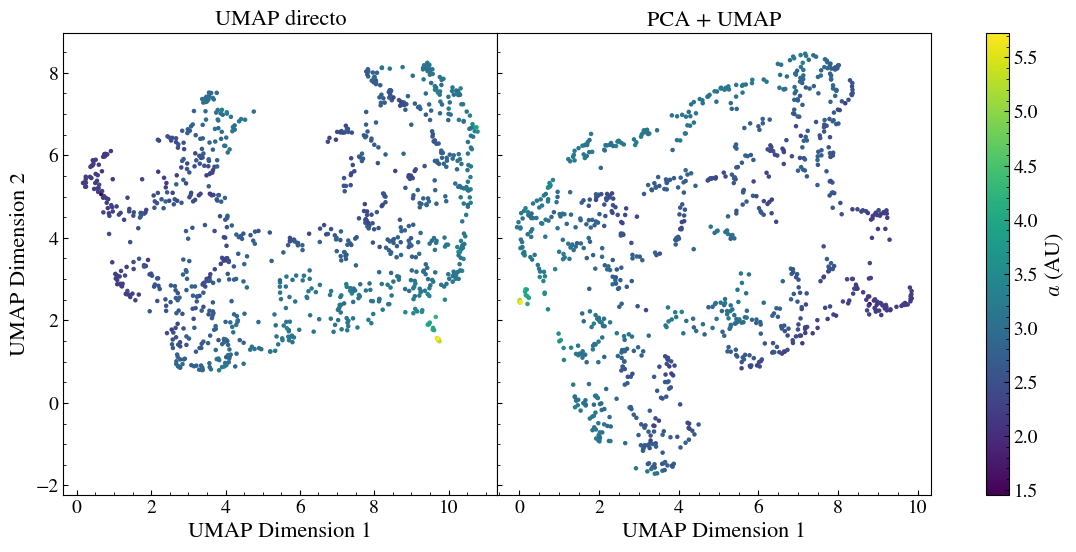

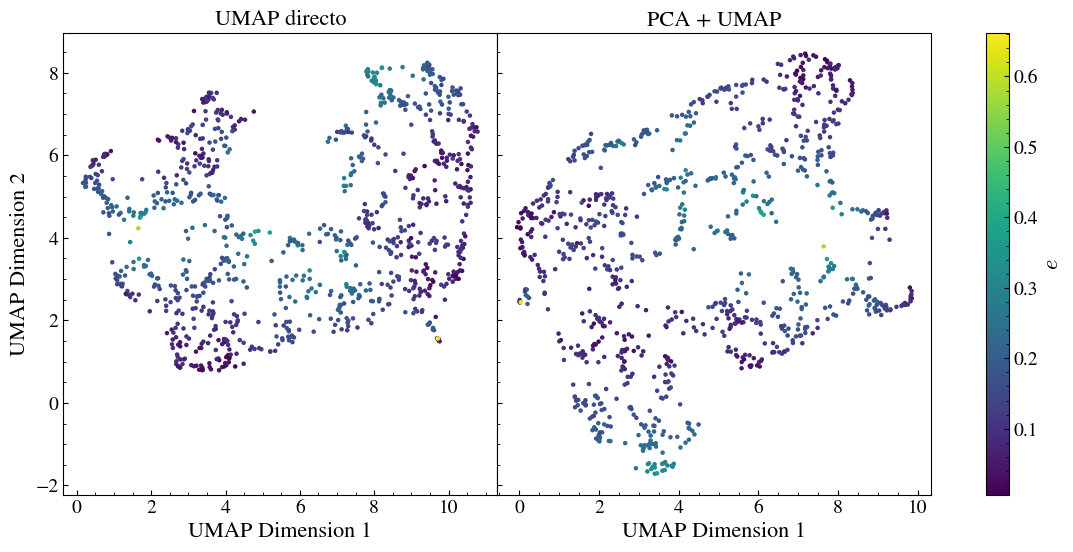

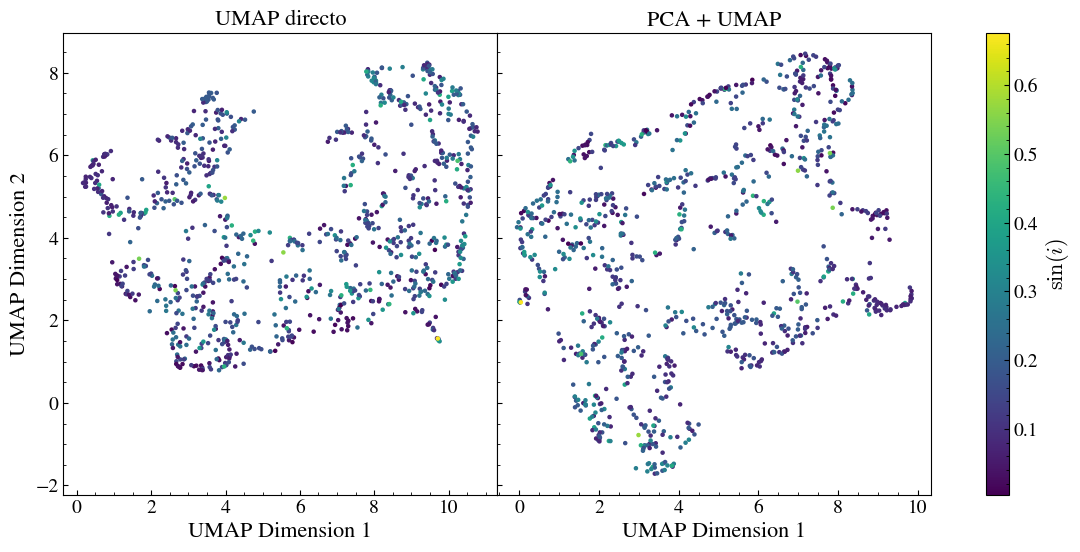

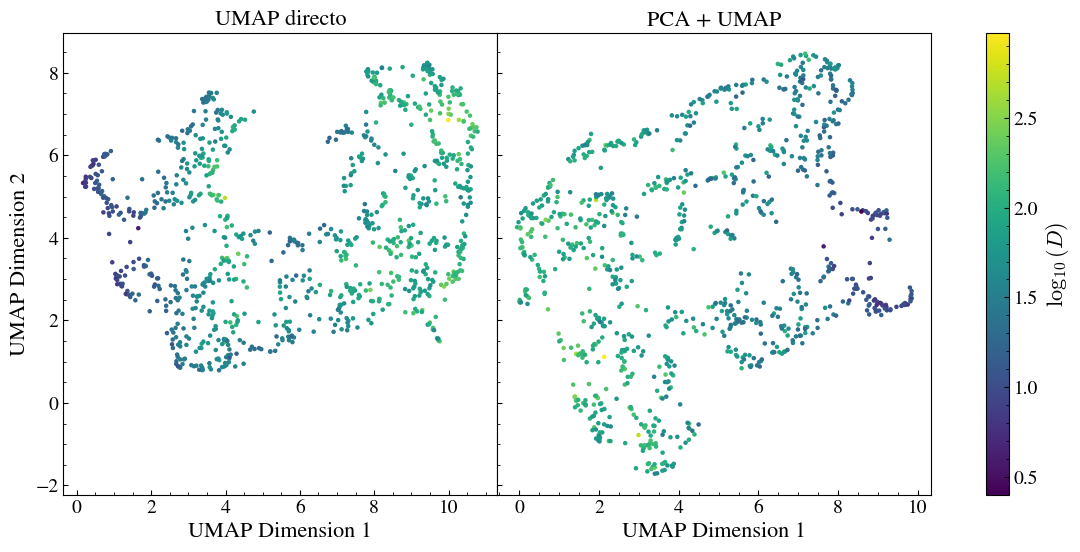

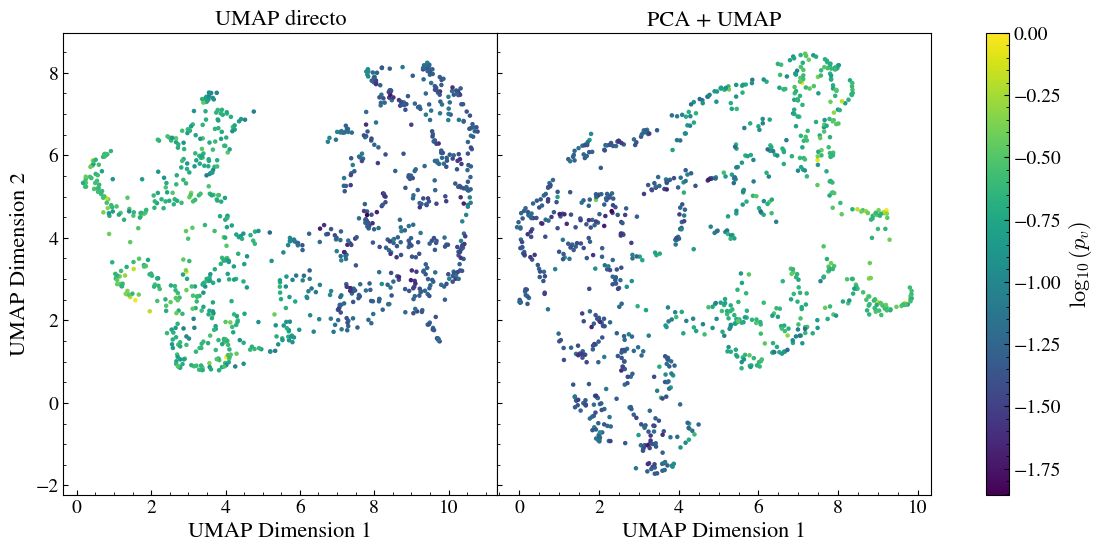

In [64]:
# Mapeo de variables a su transformación y etiqueta
feature_config = {
    'a':    (lambda x: x,           '$a$ (AU)'),
    'e':    (lambda x: x,           '$e$'),
    'sini': (lambda x: x,           r'$\sin(i)$'),       # si ya está transformada
    'logD': (lambda x: x,           r'$\log_{10}(D)$'),  # si ya está transformada
    'logpv':(lambda x: x,           r'$\log_{10}(p_v)$'),
}


for feature, (transform, label) in feature_config.items():
    color_var = transform(df[feature])
    vmin, vmax = color_var.min(), color_var.max()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, gridspec_kw={'wspace': 0})

    sc0 = axes[0].scatter(original_embedding[:, 0], original_embedding[:, 1],
                          c=color_var, s=5, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[0].set_xlabel('UMAP Dimension 1')
    axes[0].set_ylabel('UMAP Dimension 2')
    axes[0].set_title('UMAP directo')

    sc1 = axes[1].scatter(pca_pre_embedding[:, 0], pca_pre_embedding[:, 1],
                          c=color_var, s=5, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1].set_xlabel('UMAP Dimension 1')
    axes[1].set_title('PCA + UMAP')
    axes[1].tick_params(labelleft=False)

    fig.colorbar(sc1, ax=axes, label=label)
    plt.show()


## Clustering

### K-Means

K-means es un algoritmo de aprendizaje no supervisado que busca particionar un conjunto de $n$ observaciones en $k$ grupos disjuntos. La idea central es que cada observación pertenece al clúster cuyo centroide (media aritmética) es el más cercano en distancia euclidiana.

Dado un conjunto de puntos ${\mathbf{x}_1, \dots, \mathbf{x}_n} \subset \mathbb{R}^p$, queremos encontrar $k$ centroides ${\boldsymbol{\mu}_1, \dots, \boldsymbol{\mu}_k}$ y una asignación $S_1, \dots, S_k$ que minimicen la inercia (WCSS — Within-Cluster Sum of Squares):

$$J = \sum_{i=1}^{k} \sum_{\mathbf{x} \in S_i} |\mathbf{x} - \boldsymbol{\mu}_i|^2$$

donde:

- $S_i$ es el conjunto de puntos asignados al clúster $i$, con $S_i \cap S_j = \emptyset$ y $\bigcup_i S_i = {\mathbf{x}_1,\dots,\mathbf{x}_n}$ 
- $\boldsymbol{\mu}_i \in \mathbb{R}^p$ es el centroide del clúster $i$
- $|\mathbf{x} - \boldsymbol{\mu}i|^2 = \displaystyle{\sum_{d=1}^{p}(x_d - \mu_{id})^2}$ es la distancia euclidiana al cuadrado.

| Asteroide | $a$ | $e$ | $\sin i$ | $\log_{10} D$ | $\log_{10} p_v$ |
|-----------|-----|-----|----------|---------------|-----------------|
| Ceres     | 2.766 | 0.080 | 0.184 | 2.973 | −1.046 |
| Pallas    | 2.770 | 0.231 | 0.572 | 2.710 | −0.810 |
| Vesta     | 2.362 | 0.090 | 0.124 | 2.718 | −0.374 |


Cada asteroide es un vector en $\mathbb{R}^5$, por ejemplo:

$$\mathbf{x}_\text{Ceres} = (2.766,\ 0.080,\ 0.184,\ 2.973,\ {-1.046})$$

Si K-means agrupa Ceres y Pallas en el mismo clúster $S_1$, el centroide es su promedio coordenada a coordenada:

$$\boldsymbol{\mu}_1 = \frac{\mathbf{x}_\text{Ceres} + \mathbf{x}_\text{Pallas}}{2} = (2.768,\ 0.156,\ 0.378,\ 2.842,\ {-0.928})$$

Este centroide representa un asteroide "promedio" del grupo: semieje $\sim 2.77$ AU, órbita poco excéntrica, inclinación moderada, diámetro grande ($10^{2.84} \approx 700$ km) y albedo bajo (tipo C).

La contribución de Vesta a la inercia respecto a $\boldsymbol{\mu}_1$ sería:

$$|\mathbf{x}_\text{Vesta} - \boldsymbol{\mu}_1|^2 = (2.362-2.768)^2 + (0.090-0.156)^2 + \cdots \approx 0.82$$

Un valor alto indica que Vesta está lejos de ese centroide — lo que K-means interpretaría como que pertenece a otro clúster.


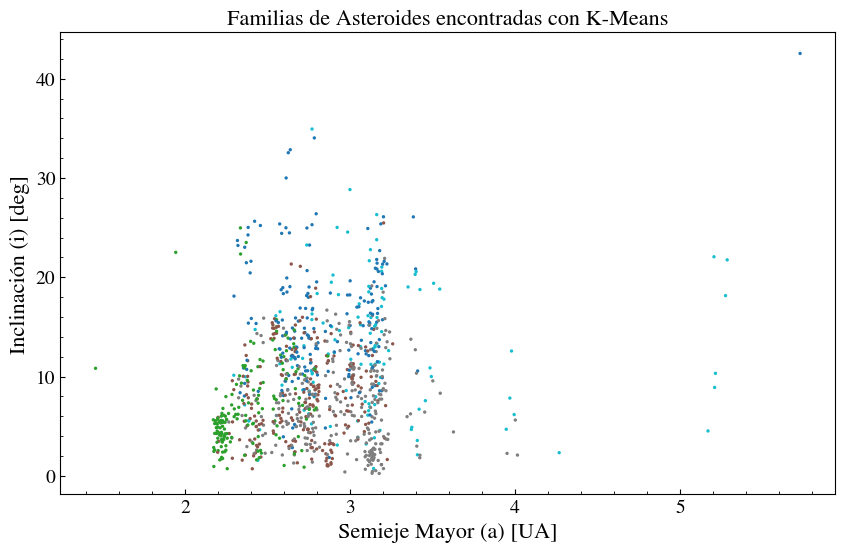

In [ ]:
from sklearn.cluster import KMeans

# Probemos con 5 clusters (puedes cambiar este número)
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Visualizamos el resultado en el espacio orbital real
plt.figure(figsize=(10, 6))
plt.scatter(df['a'], df['i'], c=df['cluster'], s=2, cmap='tab10')
plt.xlabel('Semieje Mayor (a) [UA]')
plt.ylabel('Inclinación (i) [deg]')
plt.title('Familias de Asteroides encontradas con K-Means')
plt.show()


### Density-Based Spatial CLustering of Applications with Noise (DBSCAN)

es uno de los algoritmos más potentes en astronomía porque, a diferencia de K-Means, no asume que los clústeres son "bolas" (esferas) y no te obliga a elegir el número de grupos de antemano.

DBSCAN se basa en dos hiperparámetros que definen la "densidad":
- $\epsilon$ (Epsilon): El radio de vecindad. Es la distancia máxima para considerar que dos puntos son vecinos.
- $MinPts$: El número mínimo de puntos requeridos dentro del radio $\epsilon$ para que una región se considere "densa".

Imagina un conjunto de datos $D$ en un espacio métrico con una función de distancia $d(p, q)$ (usualmente la Distancia Euclídea).

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) es uno de los algoritmos más potentes en astronomía porque, a diferencia de K-Means, no asume que los clústeres son "bolas" (esferas) y no te obliga a elegir el número de grupos de antemano.

Para tus asteroides, esto es oro: las familias en el espacio dinámico tienen formas irregulares y están rodeadas de "ruido" (asteroides de fondo).

1. Los Parámetros Fundamentales
DBSCAN se basa en dos hiperparámetros que definen la "densidad":

ϵ (Epsilon): El radio de vecindad. Es la distancia máxima para considerar que dos puntos son vecinos.

MinPts: El número mínimo de puntos requeridos dentro del radio ϵ para que una región se considere "densa".

2. Definiciones Matemáticas (El "Corazón" del Algoritmo)
Imagina un conjunto de datos D en un espacio métrico con una función de distancia d(p,q) (usualmente la Distancia Euclídea).

A. La ϵ-vecindad
Para cualquier punto p, su vecindad se define como el conjunto de puntos dentro del radio ϵ:
$$N_\epsilon(p) = \{q \in D \mid d(p, q) \leq \epsilon\}$$
B. Clasificación de Puntos
DBSCAN categoriza cada punto en tres tipos posibles:

Punto Núcleo (Core Point): Un punto p es un núcleo si tiene al menos MinPts en su vecindad (incluyéndose a sí mismo).
$$|N_\epsilon(p)| \geq MinPts$$
Punto Borde (Border Point): Un punto q no es núcleo, pero está en la vecindad de algún punto núcleo.

Ruido (Noise/Outlier): Cualquier punto que no es ni núcleo ni borde.

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) es uno de los algoritmos más potentes en astronomía porque, a diferencia de K-Means, no asume que los clústeres son "bolas" (esferas) y no te obliga a elegir el número de grupos de antemano.Para tus asteroides, esto es oro: las familias en el espacio dinámico tienen formas irregulares y están rodeadas de "ruido" (asteroides de fondo).1. Los Parámetros FundamentalesDBSCAN se basa en dos hiperparámetros que definen la "densidad":$\epsilon$ (Epsilon): El radio de vecindad. Es la distancia máxima para considerar que dos puntos son vecinos.$MinPts$: El número mínimo de puntos requeridos dentro del radio $\epsilon$ para que una región se considere "densa".2. Definiciones Matemáticas (El "Corazón" del Algoritmo)Imagina un conjunto de datos $D$ en un espacio métrico con una función de distancia $d(p, q)$ (usualmente la Distancia Euclídea).A. La $\epsilon$-vecindadPara cualquier punto $p$, su vecindad se define como el conjunto de puntos dentro del radio $\epsilon$:$$N_\epsilon(p) = \{q \in D \mid d(p, q) \leq \epsilon\}$$B. Clasificación de PuntosDBSCAN categoriza cada punto en tres tipos posibles:Punto Núcleo (Core Point): Un punto $p$ es un núcleo si tiene al menos $MinPts$ en su vecindad (incluyéndose a sí mismo).$$|N_\epsilon(p)| \geq MinPts$$Punto Borde (Border Point): Un punto $q$ no es núcleo, pero está en la vecindad de algún punto núcleo.Ruido (Noise/Outlier): Cualquier punto que no es ni núcleo ni borde.3. Relaciones de DensidadAquí es donde DBSCAN construye los clústeres mediante "conectividad":Alcanzabilidad Directa (Directly Density-Reachable): Un punto $q$ es directamente alcanzable desde $p$ si $p$ es un punto núcleo y $q \in N_\epsilon(p)$. Esta relación es asimétrica (un punto borde es alcanzable desde un núcleo, pero el núcleo no es alcanzable desde el borde).Alcanzabilidad por Densidad (Density-Reachable): Un punto $q$ es alcanzable desde $p$ si existe una cadena de puntos $p_1, p_2, \dots, p_n$ donde $p_1 = p$ y $p_n = q$, tal que cada $p_{i+1}$ es directamente alcanzable desde $p_i$.Conectividad por Densidad (Density-Connected): Dos puntos $p$ y $q$ están conectados por densidad si existe un punto núcleo $o$ tal que tanto $p$ como $q$ son alcanzables por densidad desde $o$. Esta relación es simétrica.4. Definición Matemática de un ClústerUn clúster $C$ en DBSCAN es un subconjunto de puntos que satisface dos condiciones:Maximización: Si $p \in C$ y $q$ es alcanzable por densidad desde $p$, entonces $q \in C$.Conectividad: Todos los puntos en $C$ están conectados por densidad entre sí.5. El Algoritmo en FuncionamientoEl proceso lógico es el siguiente:Se marca un punto arbitrario $p$ como visitado.Se extrae su $N_\epsilon(p)$.Si es un punto núcleo, se inicia un clúster. Si es ruido, se marca como tal (aunque luego puede convertirse en punto borde de otro clúster).Si es núcleo, se expande el clúster agregando todos los puntos en su vecindad. Si esos nuevos puntos también son núcleos, sus vecindades se unen al clúster (proceso recursivo).Se repite hasta que todos los puntos han sido procesados.6. Ventajas Críticas para AsteroidesDBSCAN es superior a K-Means en tu caso por tres razones matemáticas:Formas Arbitrarias: Las familias de asteroides suelen estirarse debido a la difusión dinámica. DBSCAN las sigue como si fuera una "mancha de aceite", mientras que K-Means intentaría cortarlas en círculos.Manejo de Outliers: En el cinturón de asteroides hay miles de objetos que no pertenecen a ninguna familia (el "background"). DBSCAN los ignora matemáticamente (los etiqueta como -1), evitando que sesguen la posición de los clústeres.No requiere $K$: No tienes que adivinar cuántas familias hay. El algoritmo las encuentra basándose en la densidad local.

**Método de la "Rodilla" (K-distance plot)**
La lógica matemática es esta: si un punto pertenece a un clúster, su distancia al vecino más cercano $k$ será pequeña. Si es ruido, esa distancia será mucho mayor. El valor de $\epsilon$ ideal es aquel donde la distancia "explota" (el codo).Cómo hacerlo paso a paso:Elegimos $k$ (usualmente el mismo valor que $MinPts$). Para asteroides, un valor de 4 a 10 es buen comienzo.Calculamos la distancia de cada asteroide a su vecino número $k$.Ordenamos esas distancias de menor a mayor.Graficamos. La "rodilla" es el punto de máxima curvatura

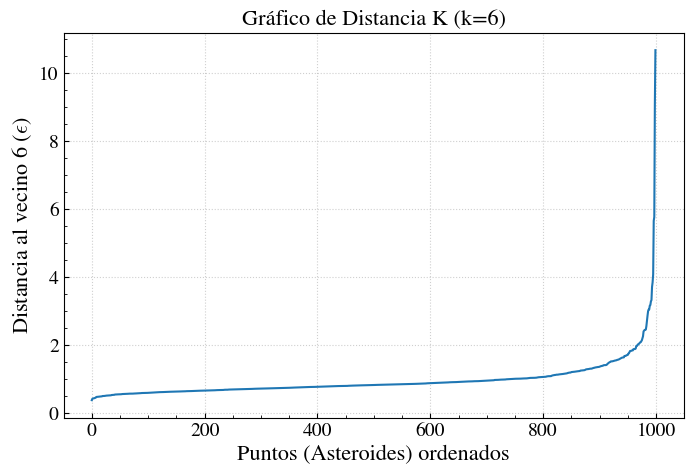

In [7]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Suponemos X_scaled (tus asteroides escalados)
k = 6 # Un valor típico para MinPts
neigh = NearestNeighbors(n_neighbors=k)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Ordenamos las distancias del k-ésimo vecino
distances = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title(f'Gráfico de Distancia K (k={k})')
plt.xlabel('Puntos (Asteroides) ordenados')
plt.ylabel(fr'Distancia al vecino {k} ($\epsilon$)')
plt.grid(True)
plt.show()

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, make_scorer

# 1. Definimos la rejilla de parámetros
param_grid = {
    'eps': [0.2, 0.3, 0.4, 0.5],
    'min_samples': [5, 10, 15]
}

results = []

# 2. Bucle de búsqueda
for eps in param_grid['eps']:
    for min_samples in param_grid['min_samples']:
        # Aplicamos DBSCAN
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)
        
        # Contamos clústeres (ignorando el ruido -1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        # Solo calculamos el score si hay una estructura válida
        if n_clusters > 1:
            score = silhouette_score(X_scaled, labels)
            results.append({
                'eps': eps, 
                'min_samples': min_samples, 
                'n_clusters': n_clusters, 
                'silhouette': score
            })

# 3. Convertimos a DataFrame para analizar
df_results = pd.DataFrame(results)
best_result = df_results.loc[df_results['silhouette'].idxmax()]

print(f"Mejor configuración: eps={best_result['eps']}, min_samples={best_result['min_samples']}")
print(f"Silhouette Score: {best_result['silhouette']:.3f}")

Mejor configuración: eps=0.4, min_samples=5.0
Silhouette Score: -0.302


¿Qué es el Silhouette Score matemáticamente?Ya que lo estás usando como métrica de validación, es clave entender qué mide realmente. El coeficiente de silueta ($s$) para un solo asteroide $i$ se calcula como:
$$s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}$$
Donde:
- $a(i)$ (Cohesión): Es la distancia promedio entre el asteroide $i$ y todos los demás puntos de su mismo clúster. Queremos que sea pequeña.
- $b(i)$ (Separación): Es la distancia promedio entre el asteroide $i$ y los puntos del clúster más cercano (el que no es el suyo). Queremos que sea grande.

Interpretación del resultado:
- $s \approx 1$: El asteroide está muy bien clasificado en su familia.
- $s \approx 0$: El asteroide está en la frontera entre dos familias (superposición).
- $s < 0$: El asteroide probablemente fue asignado a la familia incorrecta.

Número de familias encontradas: 3
Asteroides de 'fondo' (ruido): 979


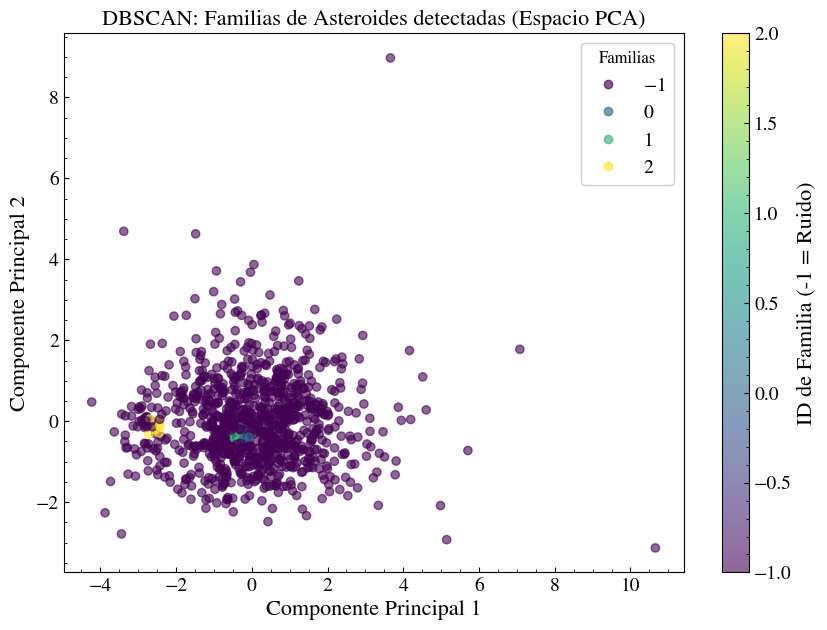

In [9]:
from sklearn.cluster import DBSCAN

# Aplicamos con los parámetros que encontramos
db = DBSCAN(eps=0.4, min_samples=5).fit(X_scaled)

# Los resultados
labels = db.labels_ # Array con el ID del clúster para cada asteroide
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Número de familias encontradas: {n_clusters}")
print(f"Asteroides de 'fondo' (ruido): {n_noise}")

plt.figure(figsize=(10, 7))

# Usamos el PCA que ya tienes (X_pca) para las coordenadas
# El color (c) son las etiquetas del DBSCAN
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.6)

# Agregamos una leyenda para los clústeres
legend1 = plt.legend(*scatter.legend_elements(), title="Familias")
plt.gca().add_artist(legend1)

plt.title('DBSCAN: Familias de Asteroides detectadas (Espacio PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(label='ID de Familia (-1 = Ruido)')
plt.show()

### Gaussian Mixture Models (GMM)

Consideremos un conjunto de datos $\mathbf{X} = \{\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_n\}$ en un espacio de $D$ dimensiones. Suponemos que los datos siguen una densidad de probabilidad que es una combinación lineal de $K$ Gaussianas:$$p(\mathbf{x}) = \sum_{k=1}^{K} \pi_k \mathcal{N}(\mathbf{x} | \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$Donde:$\pi_k$ (Mixing Coefficients): Son los pesos de cada Gaussiana. Deben cumplir que $0 \le \pi_k \le 1$ y $\sum_{k=1}^{K} \pi_k = 1$.$\mathcal{N}(\mathbf{x} | \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$: Es la distribución Normal multivariada para el componente $k$, definida como:$$\mathcal{N}(\mathbf{x} | \boldsymbol{\mu}, \boldsymbol{\Sigma}) = \frac{1}{(2\pi)^{D/2} |\boldsymbol{\Sigma}|^{1/2}} \exp \left( -\frac{1}{2} (\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu}) \right)$$3. Variables Latentes y ResponsabilidadesPara resolver el modelo, introducimos una variable latente $z$. Para cada observación $\mathbf{x}_n$, existe un vector binario $z_n$ de longitud $K$, donde $z_{nk} = 1$ si el punto fue generado por la Gaussiana $k$, y $0$ en caso contrario.La probabilidad de que un punto $\mathbf{x}_n$ pertenezca al componente $k$ se conoce como la Responsabilidad ($\gamma$):$$\gamma(z_{nk}) = p(z_k=1 | \mathbf{x}_n) = \frac{\pi_k \mathcal{N}(\mathbf{x}_n | \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)}{\sum_{j=1}^{K} \pi_j \mathcal{N}(\mathbf{x}_n | \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)}$$Este es el núcleo del soft clustering: cada punto tiene una "porción" de pertenencia a cada grupo.4. El Algoritmo Expectation-Maximization (EM)Como no conocemos qué punto pertenece a qué Gaussiana (las $z_{nk}$ son ocultas), no podemos usar Máxima Verosimilitud directamente. Usamos el algoritmo iterativo EM:Paso E (Expectation)Calculamos las responsabilidades $\gamma(z_{nk})$ para todos los puntos usando los parámetros actuales ($\pi, \boldsymbol{\mu}, \boldsymbol{\Sigma}$).Paso M (Maximization)Actualizamos los parámetros para maximizar la verosimilitud, usando las responsabilidades calculadas:Nuevas medias: $\boldsymbol{\mu}_k^{new} = \frac{1}{N_k} \sum_{n=1}^N \gamma(z_{nk}) \mathbf{x}_n$Nuevas covarianzas: $\boldsymbol{\Sigma}_k^{new} = \frac{1}{N_k} \sum_{n=1}^N \gamma(z_{nk}) (\mathbf{x}_n - \boldsymbol{\mu}_k^{new})(\mathbf{x}_n - \boldsymbol{\mu}_k^{new})^T$Nuevos pesos: $\pi_k^{new} = \frac{N_k}{N}$Donde $N_k = \sum_{n=1}^N \gamma(z_{nk})$ es el número efectivo de puntos asignados al componente $k$.5. Selección del Modelo: BIC y AICA diferencia de K-Means, donde el "codo" es algo subjetivo, en GMM podemos usar criterios de información para penalizar la complejidad del modelo (evitar el overfitting).BIC (Bayesian Information Criterion):$$BIC = \ln(n)k - 2\ln(\hat{L})$$AIC (Akaike Information Criterion):$$AIC = 2k - 2\ln(\hat{L})$$Donde $k$ es el número de parámetros y $\hat{L}$ es el máximo de la función de verosimilitud. El modelo con el menor BIC/AIC es el preferido.Resumen de Comparación para la clase:CaracterísticaK-MeansGMMTipo de asignaciónHard (0 o 1)Soft (Probabilística)Forma del clusterEsférica (Distancia $L_2$)Elipsoidal (Cualquier orientación)ParámetrosSolo mediasMedias, pesos y CovarianzasFlexibilidadLimitadaAlta (Captura geometrías complejas)

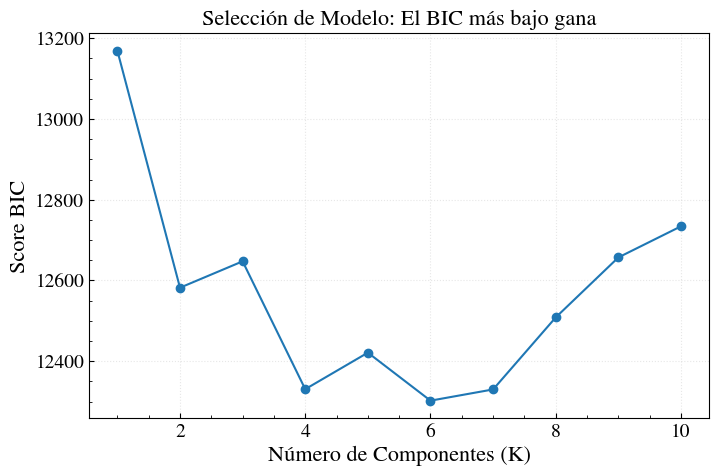

Probabilidades del primer asteroide: [0. 0. 1.]


In [10]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# 1. Preparación de datos (usando log para variables físicas)
features = ['a', 'e', 'i', 'H', 'D', 'pv']
X = df[features].dropna().copy()
X['D'] = np.log10(X['D'])
X['pv'] = np.log10(X['pv'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Encontrar el número óptimo de componentes usando BIC
n_components = np.arange(1, 11)
models = [GaussianMixture(n, covariance_type='full', random_state=42).fit(X_scaled)
          for n in n_components]

plt.figure(figsize=(8, 5))
plt.plot(n_components, [m.bic(X_scaled) for m in models], label='BIC', marker='o')
plt.title('Selección de Modelo: El BIC más bajo gana')
plt.xlabel('Número de Componentes (K)')
plt.ylabel('Score BIC')
plt.grid(alpha=0.3)
plt.show()

# 3. Aplicar el mejor modelo (supongamos K=3 basado en el BIC)
best_gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
labels_gmm = best_gmm.fit_predict(X_scaled)
probs = best_gmm.predict_proba(X_scaled) # Aquí está el "Soft Clustering"

print(f"Probabilidades del primer asteroide: {probs[0].round(3)}")

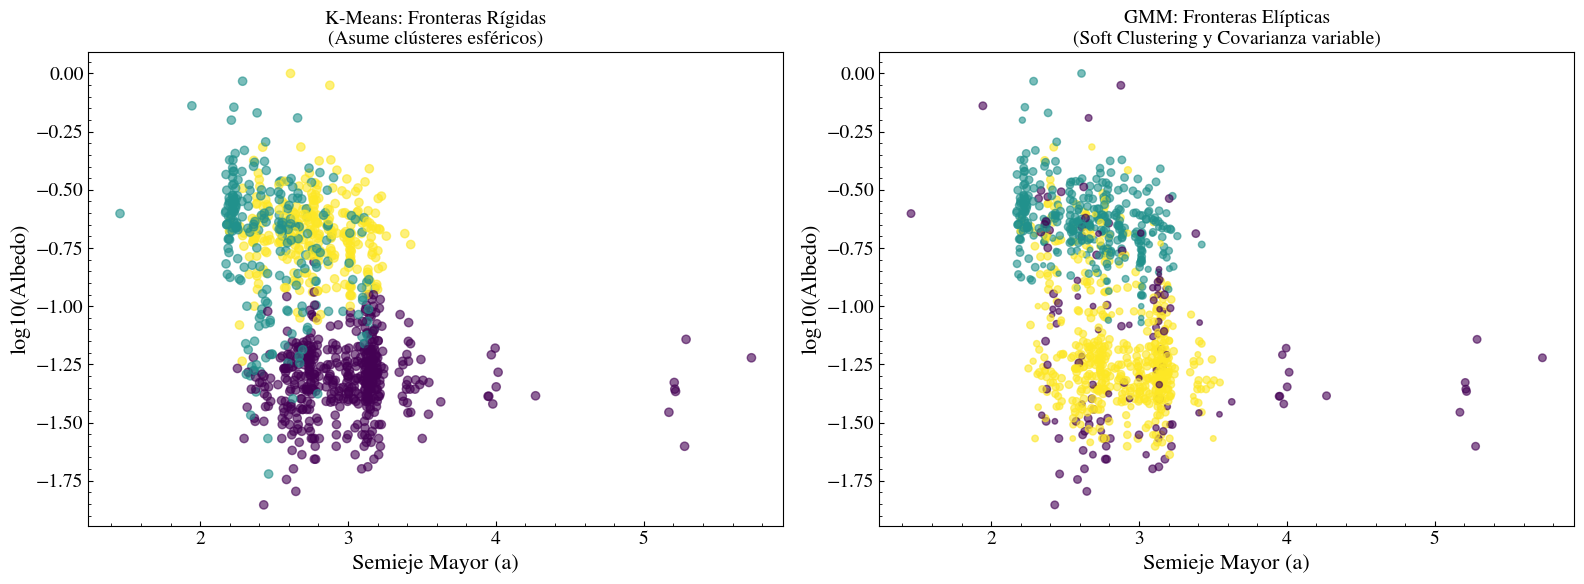

In [11]:
from sklearn.cluster import KMeans

# Configuración de la comparación
n_clusters = 3
km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels_km = km.fit_predict(X_scaled)

gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=42)
labels_gmm = gmm.fit_predict(X_scaled)

# Visualización en el plano Albedo vs Semieje Mayor (a)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot K-Means
ax1.scatter(X['a'], X['pv'], c=labels_km, cmap='viridis', alpha=0.6)
ax1.set_title(f'K-Means: Fronteras Rígidas\n(Asume clústeres esféricos)', fontsize=14)
ax1.set_xlabel('Semieje Mayor (a)')
ax1.set_ylabel('log10(Albedo)')

# Plot GMM
# El tamaño del punto puede representar la "certeza" (max prob)
probs_max = gmm.predict_proba(X_scaled).max(axis=1)
ax2.scatter(X['a'], X['pv'], c=labels_gmm, cmap='viridis', alpha=0.6, s=probs_max*30)
ax2.set_title(f'GMM: Fronteras Elípticas\n(Soft Clustering y Covarianza variable)', fontsize=14)
ax2.set_xlabel('Semieje Mayor (a)')
ax2.set_ylabel('log10(Albedo)')

plt.tight_layout()
plt.show()

Puntos clave para comentar en la clase auxiliar:La Tiranía de la Esfera: Explícales que K-Means minimiza la varianza dentro del clúster basándose en la distancia $L_2$ (Euclídea), lo que obliga a los grupos a ser circulares. Si una familia de asteroides está "estirada" en el plano dinámico, K-Means la romperá por la mitad.La Libertad de la Elipse: GMM tiene una matriz de covarianza $\boldsymbol{\Sigma}_k$ para cada componente. Esto permite que el modelo rote y se estire en cualquier dirección. En astronomía, esto es vital porque las leyes físicas (como las resonancias) suelen crear estructuras no esféricas.Incertidumbre: En el código de GMM, usamos predict_proba. Muéstrales cómo un asteroide que vive justo entre dos familias tiene una probabilidad de $\sim 0.5$ para ambas. K-Means, en cambio, le "mentiría" al alumno asignándolo a una sola con 100% de certeza.

## Clustering Herarchical

A. Métricas de DistanciaPrimero, necesitamos una forma de medir qué tan lejos están dos asteroides $i$ y $j$. La más común es la Distancia Euclídea:$$d(x_i, x_j) = \sqrt{\sum_{k=1}^{p} (x_{ik} - x_{jk})^2}$$Donde $p$ son nuestras características ($a, e, i, H$, etc.).B. Criterios de Enlace (Linkage)Aquí es donde reside la verdadera matemática del algoritmo. Una vez que sabemos la distancia entre puntos, ¿cómo medimos la distancia entre grupos de puntos (clústeres)?Single Linkage (Enlace Simple): Distancia mínima entre un punto del clúster A y uno del B. Tiende a crear clústeres alargados ("encadenamiento").$$D(A, B) = \min \{d(a, b) : a \in A, b \in B\}$$Complete Linkage (Enlace Completo): Distancia máxima. Produce clústeres compactos y esféricos.$$D(A, B) = \max \{d(a, b) : a \in A, b \in B\}$$Average Linkage (Enlace Promedio): Promedio de todas las distancias par a par.$$D(A, B) = \frac{1}{|A||B|} \sum_{a \in A} \sum_{b \in B} d(a, b)$$Ward's Method: Minimiza el incremento en la varianza total dentro de los clústeres al fusionarlos. Es el más robusto y común en astronomía porque busca clústeres densos y bien separados.2. El Dendrograma: La Genealogía de los DatosUn dendrograma es un diagrama de árbol que registra las fusiones.Eje X: Representa los objetos o clústeres individuales.Eje Y: Representa la distancia (o disimilitud) a la que se ocurrió la fusión.Interpretación: Cuanto más alta sea la "U" invertida que une dos grupos, más diferentes son esos grupos entre sí.

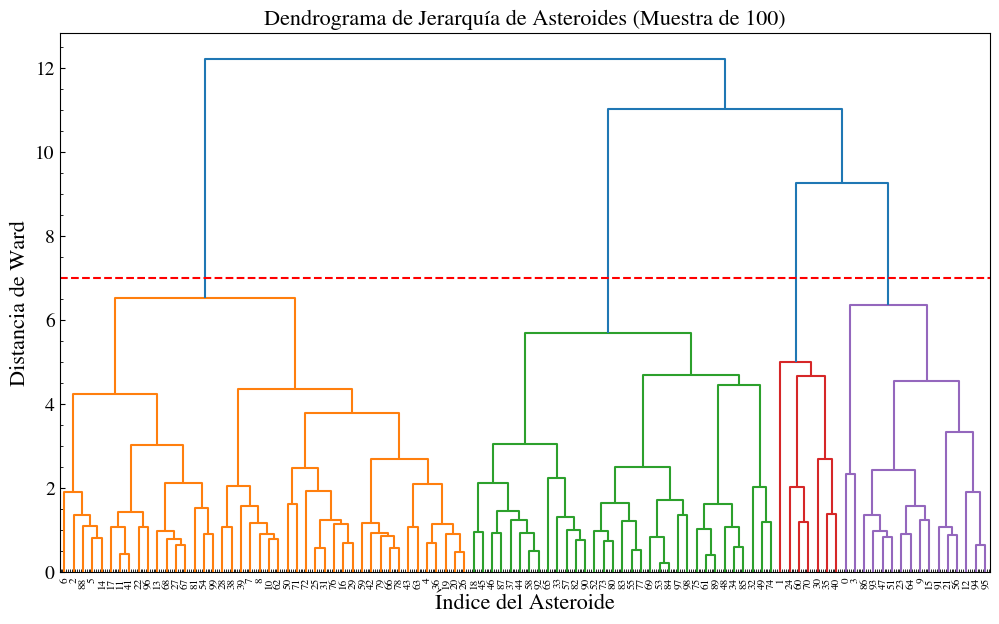

In [15]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

# 1. Preparación de datos (usando solo 50-100 para que el dendrograma sea legible)
# Si usas 1000 puntos, el eje X será una mancha negra.
X_sample = X_scaled[:100] 

# 2. Calcular la matriz de enlace (Linkage Matrix)
# Usamos el método de Ward y distancia euclídea
Z = linkage(X_sample, method='ward')

# 3. Graficar el Dendrograma
plt.figure(figsize=(12, 7))
dendrogram(
    Z,
    leaf_rotation=90.,  # Rota los nombres en el eje X
    leaf_font_size=8.,  # Tamaño de fuente
    color_threshold=7   # Altura a la cual se cambia de color (ayuda a visualizar cortes)
)

plt.title('Dendrograma de Jerarquía de Asteroides (Muestra de 100)')
plt.xlabel('Índice del Asteroide')
plt.ylabel('Distancia de Ward')
plt.axhline(y=7, color='r', linestyle='--') # Línea de "corte" hipotética
plt.show()